# II.2 Limites e derivadas em múltiplas variáveis

No notebook [II.1](II.1_funcoes_multiplas_variaveis.ipynb) vimos como representar graficamente funções de várias variáveis. Agora vamos estender para funções de duas (ou mais) variáveis os conceitos de **limite** e **derivada**, já conhecidos do Cálculo de uma variável. Esses conceitos são a base para as aplicações que veremos em [II.3](II.3_aplicacoes_do_calculo_multivariado.ipynb) (plano tangente, aproximação linear, taxas relacionadas) e para o estudo de máximos e mínimos em [II.4](II.4_maximos_e_minimos_funcoes_de_duas_variaveis.ipynb).

Ao longo deste notebook, vamos calcular limites e derivadas de duas formas complementares:

- **Simbolicamente**, com o `sympy`, que manipula expressões matemáticas de forma exata e fornece resultados fechados (fórmulas), mas exige que saibamos exatamente qual conta queremos fazer — por exemplo, ao longo de qual caminho tomamos um limite.
- **Numericamente**, com o `numpy`, que trabalha com valores aproximados (de ponto flutuante) e é útil para explorar o comportamento de uma função, detectar padrões e confirmar (ou refutar) hipóteses, mas está sujeito a erros de arredondamento e de truncamento.

Essa distinção entre computação **simbólica** e computação **numérica** vai aparecer repetidamente: sempre que possível, vamos comparar as duas abordagens.

## Limites de funções de duas variáveis

Dizemos que

$$ \lim_{(x,y)\to(a,b)} f(x,y) = L $$

se os valores de $f(x,y)$ se aproximam de $L$ à medida que o ponto $(x,y)$ se aproxima de $(a,b)$, **por qualquer caminho** contido no domínio de $f$.

Essa exigência é a grande diferença em relação ao limite de uma função de uma variável: em $\mathbb{R}$, um ponto pode ser aproximado apenas pela esquerda ou pela direita, mas em $\mathbb{R}^2$ existem infinitos caminhos possíveis para se aproximar de $(a,b)$ — retas de diversas inclinações, parábolas, espirais, etc. Se o valor obtido depender do caminho escolhido, dizemos que o **limite não existe**.

**Exemplo 1:** Vamos investigar se existe o limite

$$ \lim_{(x,y)\to(0,0)} \frac{xy^2}{x^2+y^4} $$

Primeiro, vamos explorar numericamente o comportamento da função ao longo de retas $y=mx$ que passam pela origem, para diferentes valores de $m$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x, y: x*y**2/(x**2 + y**4)

# aproximando (0,0) ao longo de retas y = m*x, para diferentes valores de m
t = np.array([0.1, 0.01, 0.001, 0.0001])

for m in [0, 0.5, 1, 2, 5]:
    xv = t
    yv = m*t
    print(f'm={m}:', np.round(f(xv, yv), 6))

m=0: [0. 0. 0. 0.]
m=0.5: [2.4984e-02 2.5000e-03 2.5000e-04 2.5000e-05]
m=1: [0.09901  0.009999 0.001    0.0001  ]
m=2: [0.344828 0.039936 0.004    0.0004  ]
m=5: [0.344828 0.235294 0.024984 0.0025  ]


Para todos os valores de $m$ testados, os valores de $f(x,mx)$ se aproximam de $0$ conforme $x\to 0$. Isso é confirmado simbolicamente com `sympy`, substituindo $y=mx$ e calculando o limite quando $x\to 0$.

In [2]:
import sympy as sp

x, y, m = sp.symbols('x y m')
f_exp = x*y**2/(x**2 + y**4)

sp.limit(f_exp.subs(y, m*x), x, 0)

0

O resultado é $0$ para **qualquer** valor de $m$, o que sugere (mas não prova) que o limite existe e vale $0$. Porém, retas não são os únicos caminhos possíveis. Vamos tentar agora o caminho parabólico $x=y^2$.

In [3]:
t = np.array([0.1, 0.01, 0.001, 0.0001])

xv = t**2
yv = t
print('Ao longo de x = y^2:', np.round(f(xv, yv), 6))

Ao longo de x = y^2: [0.5 0.5 0.5 0.5]


Ao longo dessa parábola os valores se aproximam de $0{,}5$, e não de $0$! Vamos confirmar simbolicamente:

In [4]:
sp.limit(f_exp.subs(x, y**2), y, 0)

1/2

Como caminhos diferentes levam a valores diferentes, concluímos que

$$ \lim_{(x,y)\to(0,0)} \frac{xy^2}{x^2+y^4} \quad \text{não existe.} $$

Esse exemplo evidencia os limites de cada abordagem: a exploração **numérica** com retas sugeriu, erradamente, que o limite existia, pois testamos apenas uma família de caminhos; já o cálculo **simbólico**, embora exato para cada caminho testado, também depende de sabermos *qual* caminho testar. O `sympy` não possui uma função pronta para calcular diretamente limites de duas variáveis simultaneamente — cabe a nós, com base na exploração numérica e na forma da expressão, escolher caminhos relevantes para testar.

## Continuidade

Uma função $f(x,y)$ é **contínua** em $(a,b)$ se

$$ \lim_{(x,y)\to(a,b)} f(x,y) = f(a,b) $$

Assim como no caso de uma variável, somas, produtos, quocientes (com denominador não nulo) e composições de funções contínuas são contínuas. A função do Exemplo 1, por exemplo, não pode ser definida de forma contínua em $(0,0)$, pois o limite ali nem sequer existe.

## Derivadas parciais

Se $f$ é uma função de duas variáveis, suas **derivadas parciais** em relação a $x$ e a $y$ são definidas, respectivamente, por

$$
f_x(x,y) = \lim_{h\to 0} \frac{f(x+h,y)-f(x,y)}{h}, \qquad
f_y(x,y) = \lim_{h\to 0} \frac{f(x,y+h)-f(x,y)}{h}
$$

ou seja, derivamos em relação a uma variável, tratando a outra como constante. Geometricamente, $f_x(a,b)$ e $f_y(a,b)$ são as inclinações das retas tangentes à superfície $z=f(x,y)$ no ponto $(a,b,f(a,b))$, nas direções dos eixos $x$ e $y$, respectivamente.

**Exemplo 2: (Derivadas parciais com Sympy)** Vamos agora usar a função `diff`do Sympy para calcular as derivadas parciais de uma função escalar de duas variáveis e construir alguns gráficos

In [5]:
import sympy as sp
x, y = sp.symbols('x y')
f = sp.Function('f')(x,y)

In [6]:
f_exp = (sp.sin(x)*sp.sin(y))/(x*y)
display(sp.Eq(f,f_exp))

Eq(f(x, y), sin(x)*sin(y)/(x*y))

In [7]:
display(sp.Eq(f.diff(x),f_exp.diff(x)))

Eq(Derivative(f(x, y), x), sin(y)*cos(x)/(x*y) - sin(x)*sin(y)/(x**2*y))

In [8]:
display(sp.Eq(f.diff(y),f_exp.diff(y)))

Eq(Derivative(f(x, y), y), sin(x)*cos(y)/(x*y) - sin(x)*sin(y)/(x*y**2))

In [9]:
f = sp.lambdify([x,y],f_exp)
dfdx = sp.lambdify([x,y],f_exp.diff(x))
dfdy = sp.lambdify([x,y],f_exp.diff(y))

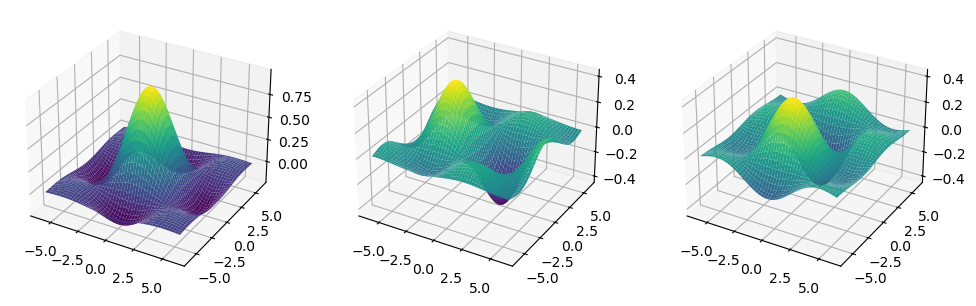

In [10]:
x, y = np.meshgrid(np.linspace(-6,6), 
                   np.linspace(-6,6))

fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(131,projection="3d")
ax1.plot_surface(x, y, f(x,y),cmap='viridis', edgecolor='none')

ax2 = fig.add_subplot(132,projection="3d")
ax2.plot_surface(x, y, dfdx(x,y),cmap='viridis', edgecolor='none')

ax3 = fig.add_subplot(133,projection="3d")
ax3.plot_surface(x, y, dfdy(x,y),cmap='viridis', edgecolor='none')
plt.show()

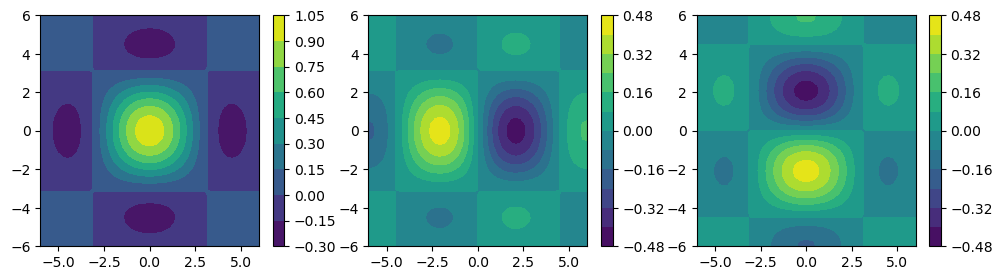

In [11]:
fig = plt.figure(figsize=(12,3))
ax1 = fig.add_subplot(131)
cont1 = ax1.contourf(x, y, f(x,y), 10)
fig.colorbar(cont1, ax=ax1)

ax2 = fig.add_subplot(132)
cont2 = ax2.contourf(x, y, dfdx(x,y), 10)
fig.colorbar(cont2, ax=ax2)

ax3 = fig.add_subplot(133)
cont3 = ax3.contourf(x, y, dfdy(x,y), 10)
fig.colorbar(cont3, ax=ax3)
plt.show()

Vamos fazer o gráfico da função módulo do vetor gradiente $\mid \nabla f \mid = \sqrt{\left(\frac{\partial f}{\partial x} \right) ^2 + \left( \frac{\partial f}{\partial y}\right)^2}$.

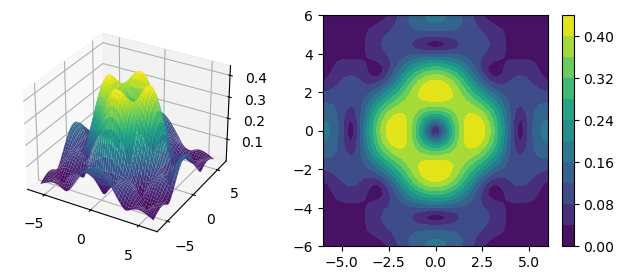

In [12]:
fig = plt.figure(figsize=(8,3))
grad_mod = np.sqrt(dfdx(x,y)**2+dfdy(x,y)**2)

ax1 = fig.add_subplot(121,projection="3d")
ax1.plot_surface(x, y, grad_mod,cmap='viridis', edgecolor='none')

ax2 = fig.add_subplot(122)
cont = ax2.contourf(x, y, grad_mod, 10)
fig.colorbar(cont, ax=ax2)
plt.show()

**Exemplo 3:** Considere $f(x,y) = x^2e^{-y} + \operatorname{sen}(xy)$. Vamos calcular $f_x$ e $f_y$ simbolicamente com `sympy` e, em seguida, aproximá-las numericamente pela própria definição de limite, usando um valor pequeno de $h$.

In [13]:
x, y = sp.symbols('x y')
f_exp = x**2*sp.exp(-y) + sp.sin(x*y)

dfdx = sp.diff(f_exp, x)
dfdy = sp.diff(f_exp, y)
display(dfdx)
display(dfdy)

2*x*exp(-y) + y*cos(x*y)

-x**2*exp(-y) + x*cos(x*y)

In [14]:
# avaliando as derivadas parciais exatas no ponto (1, 0)
ponto = {x: 1, y: 0}
print('fx(1,0) exato =', dfdx.subs(ponto))
print('fy(1,0) exato =', dfdy.subs(ponto))

fx(1,0) exato = 2
fy(1,0) exato = 0


Agora vamos aproximar essas mesmas derivadas usando **diferenças finitas**, isto é, aplicando diretamente a definição com um valor pequeno (mas não nulo) de $h$.

In [15]:
f = lambda x, y: x**2*np.exp(-y) + np.sin(x*y)

a, b = 1.0, 0.0
h = 1e-5

fx_num = (f(a+h, b) - f(a, b))/h
fy_num = (f(a, b+h) - f(a, b))/h

print('fx(1,0) numérico =', fx_num)
print('fy(1,0) numérico =', fy_num)

fx(1,0) numérico = 2.00001000001393
fy(1,0) numérico = 4.99995600478087e-06


Os valores numéricos aproximam bem os valores exatos obtidos simbolicamente. Mas a qualidade dessa aproximação depende fortemente da escolha de $h$: valores muito grandes tornam a aproximação imprecisa (erro de truncamento), enquanto valores muito pequenos podem gerar erro de arredondamento (cancelamento catastrófico), pois estamos subtraindo dois números de ponto flutuante muito próximos. Vamos visualizar esse comportamento.

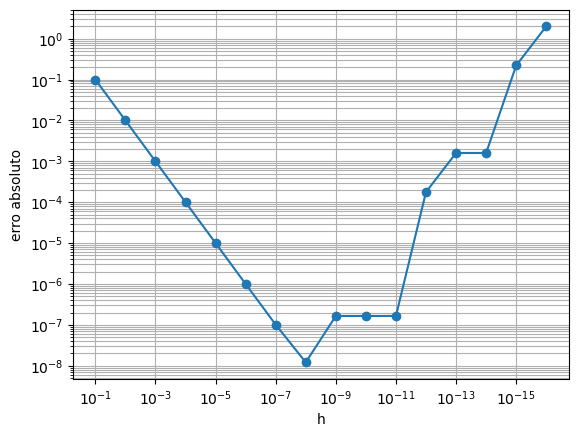

In [16]:
hs = np.logspace(-1, -16, 16)
erros = []

fx_exato = float(dfdx.subs(ponto))
for h in hs:
    fx_num = (f(a+h, b) - f(a, b))/h
    erros.append(abs(fx_num - fx_exato))

import matplotlib.pyplot as plt
plt.loglog(hs, erros, 'o-')
plt.xlabel('h')
plt.ylabel('erro absoluto')
plt.gca().invert_xaxis()
plt.grid(True, which='both')
plt.show()

O gráfico mostra o comportamento típico da diferenciação numérica: o erro diminui conforme $h$ diminui, até um ponto em que o erro de arredondamento passa a dominar e o erro volta a crescer. Essa é uma limitação prática do cálculo **numérico** que simplesmente não existe no cálculo **simbólico** — a derivada exata, obtida com `sympy`, não depende de nenhuma escolha de passo $h$.

## Derivadas parciais de ordem superior

Podemos derivar $f_x$ e $f_y$ novamente, obtendo as **derivadas parciais de segunda ordem**:

$$
f_{xx} = \frac{\partial}{\partial x}\left(\frac{\partial f}{\partial x}\right), \quad
f_{yy} = \frac{\partial}{\partial y}\left(\frac{\partial f}{\partial y}\right), \quad
f_{xy} = \frac{\partial}{\partial y}\left(\frac{\partial f}{\partial x}\right), \quad
f_{yx} = \frac{\partial}{\partial x}\left(\frac{\partial f}{\partial y}\right)
$$

**Teorema de Clairaut:** se $f_{xy}$ e $f_{yx}$ forem contínuas em uma região, então $f_{xy}=f_{yx}$ nessa região, ou seja, a ordem de derivação não importa. Essa propriedade é usada, por exemplo, no teste da derivada segunda para classificar pontos críticos, em [II.4](II.4_maximos_e_minimos_funcoes_de_duas_variaveis.ipynb).

**Exemplo 4:** Vamos verificar o Teorema de Clairaut para $f(x,y)=x^3y^2 - \cos(xy)$, usando `sympy`.

In [17]:
x, y = sp.symbols('x y')
f_exp = x**3*y**2 - sp.cos(x*y)

fxy = sp.diff(f_exp, x, y)
fyx = sp.diff(f_exp, y, x)

display(fxy)
display(fyx)
sp.simplify(fxy - fyx) == 0

6*x**2*y + x*y*cos(x*y) + sin(x*y)

6*x**2*y + x*y*cos(x*y) + sin(x*y)

True

## Diferenciabilidade

A existência das derivadas parciais $f_x$ e $f_y$ em um ponto **não garante** que $f$ seja contínua (nem diferenciável) nesse ponto — diferente do que ocorre com funções de uma variável. Dizemos que $f$ é **diferenciável** em $(a,b)$ quando existe uma boa aproximação linear (o plano tangente) para $f$ próximo desse ponto; essa ideia será explorada com mais detalhes em [II.3](II.3_aplicacoes_do_calculo_multivariado.ipynb). Uma condição suficiente (mas não necessária) para a diferenciabilidade é que $f_x$ e $f_y$ existam e sejam contínuas em uma vizinhança do ponto.

## Regra da cadeia

Se $z=f(x,y)$ é diferenciável e $x=x(t)$, $y=y(t)$ são funções diferenciáveis de $t$, então

$$ \frac{dz}{dt} = \frac{\partial f}{\partial x}\frac{dx}{dt} + \frac{\partial f}{\partial y}\frac{dy}{dt} $$

**Exemplo 5:** Seja $z = f(x,y) = x^2y + y^3$, com $x(t)=\cos t$ e $y(t) = \operatorname{sen} t$. Vamos calcular $\dfrac{dz}{dt}$ de duas formas com `sympy` — pela regra da cadeia, e substituindo $x(t)$ e $y(t)$ diretamente em $z$ antes de derivar — e comparar os resultados.

In [18]:
t = sp.symbols('t')
x_t = sp.cos(t)
y_t = sp.sin(t)

x, y = sp.symbols('x y')
z = x**2*y + y**3

dzdx = sp.diff(z, x)
dzdy = sp.diff(z, y)

dzdt_cadeia = dzdx.subs({x: x_t, y: y_t})*sp.diff(x_t, t) + dzdy.subs({x: x_t, y: y_t})*sp.diff(y_t, t)
sp.simplify(dzdt_cadeia)

cos(t)

In [19]:
z_t = z.subs({x: x_t, y: y_t})
dzdt_direto = sp.diff(z_t, t)
sp.simplify(dzdt_direto)

cos(t)

In [20]:
sp.simplify(dzdt_cadeia - dzdt_direto) == 0

True

## Derivada direcional e vetor gradiente

A derivada parcial $f_x$ mede a taxa de variação de $f$ na direção do eixo $x$, e $f_y$ na direção do eixo $y$. A **derivada direcional** generaliza essa ideia para uma direção qualquer, dada por um vetor unitário $\mathbf{u}=(u_1,u_2)$:

$$ D_{\mathbf u} f(a,b) = f_x(a,b)\,u_1 + f_y(a,b)\,u_2 = \nabla f(a,b)\cdot \mathbf u $$

em que

$$\nabla f(x,y) = \left(f_x(x,y),\, f_y(x,y)\right)$$

é o **vetor gradiente** de $f$. O gradiente aponta na direção de maior crescimento de $f$, e seu módulo $|\nabla f|$ é a taxa máxima de crescimento nesse ponto. Além disso, o gradiente é sempre perpendicular às curvas de nível de $f$.

**Exemplo 6:** Considere $f(x,y) = x^2 + y^2 - 2x$. Vamos calcular o gradiente simbolicamente, avaliá-lo em $(3,1)$, e usar essa informação para calcular a derivada direcional na direção do vetor $\mathbf{v}=(1,1)$. Em seguida, vamos comparar o gradiente exato com uma aproximação numérica obtida por diferenças finitas.

In [21]:
x, y = sp.symbols('x y')
f_exp = x**2 + y**2 - 2*x

grad = sp.Matrix([sp.diff(f_exp, x), sp.diff(f_exp, y)])
display(grad)

grad_31 = grad.subs({x: 3, y: 1})
display(grad_31)

Matrix([
[2*x - 2],
[    2*y]])

Matrix([
[4],
[2]])

In [22]:
v = np.array([1, 1])
u = v/np.linalg.norm(v)  # vetor unitário

grad_np = np.array(grad_31.tolist(), dtype=float).flatten()
D_u = np.dot(grad_np, u)
print('Vetor unitário u =', u)
print('Derivada direcional D_u f(3,1) =', D_u)

Vetor unitário u = [0.70710678 0.70710678]
Derivada direcional D_u f(3,1) = 4.242640687119285


In [23]:
# aproximando o gradiente numericamente por diferenças finitas centradas
f = lambda x, y: x**2 + y**2 - 2*x
h = 1e-6
a, b = 3.0, 1.0

fx_num = (f(a+h, b) - f(a-h, b))/(2*h)
fy_num = (f(a, b+h) - f(a, b-h))/(2*h)

print('Gradiente numérico: ', np.round([fx_num, fy_num], 6))
print('Gradiente simbólico:', grad_np)

Gradiente numérico:  [4. 2.]
Gradiente simbólico: [4. 2.]


Vamos visualizar o vetor gradiente sobre as curvas de nível de $f$, confirmando que ele aponta na direção de maior crescimento e é perpendicular às curvas de nível.

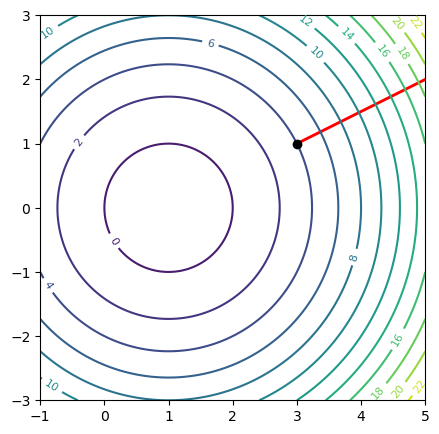

In [24]:
xi, yi = np.meshgrid(np.linspace(-1, 5, 200), np.linspace(-3, 3, 200))
zi = f(xi, yi)

fig, ax = plt.subplots(figsize=(5,5))
c = ax.contour(xi, yi, zi, 15, cmap='viridis')
ax.clabel(c, inline=2, fontsize=8)

ax.quiver(3, 1, grad_np[0], grad_np[1], color='r', angles='xy', scale_units='xy', scale=1)
ax.plot(3, 1, 'ko')
ax.set_aspect('equal')
plt.show()

### Atividades:

**1.** Investigue se existe o limite

$$\lim_{(x,y)\to(0,0)} \frac{2x^2y}{x^4+y^2}$$

Explore numericamente o comportamento ao longo de retas $y=mx$ e, em seguida, tente o caminho $y=x^2$. Confirme suas conclusões simbolicamente com `sympy`.

In [25]:
# Cole e/ou escreva seu código aqui

**2.** Para $f(x,y) = \ln(x^2+y^2+1)$, calcule $f_x$ e $f_y$ simbolicamente com `sympy`. Em seguida, aproxime numericamente essas derivadas no ponto $(1,2)$ usando diferenças finitas com $h=10^{-4}$ e compare com os valores exatos.

In [26]:
# Cole e/ou escreva seu código aqui

**3.** Verifique o Teorema de Clairaut para $f(x,y) = e^{xy}\operatorname{sen}(x+y)$, calculando $f_{xy}$ e $f_{yx}$ com `sympy`.

In [27]:
# Cole e/ou escreva seu código aqui

**4.** Se $z=f(x,y)=xe^y$, com $x=t^2$ e $y=1-t$, determine $\dfrac{dz}{dt}$ em $t=1$, usando a regra da cadeia e também por substituição direta. Confirme que os dois resultados coincidem, como no Exemplo 5.

In [28]:
# Cole e/ou escreva seu código aqui

**5.** Para $f(x,y) = xy^2 - x^3$, calcule $\nabla f$ no ponto $(2,-1)$. Determine a derivada direcional nesse ponto na direção do vetor $\mathbf v=(3,4)$. Em que direção $f$ cresce mais rapidamente a partir de $(2,-1)$, e qual é a taxa máxima de crescimento?

In [29]:
# Cole e/ou escreva seu código aqui

**6.** (Simbólico × numérico) Escreva uma função Python que aproxime numericamente o vetor gradiente de qualquer função de duas variáveis em um ponto dado, usando diferenças finitas centradas (como no Exemplo 6). Teste-a com uma função à sua escolha e compare o resultado com o gradiente exato calculado via `sympy`.

In [30]:
# Cole e/ou escreva seu código aqui

### Referências

GUIDORIZZI, Hamilton L. Um Curso de Cálculo - Volume 2. 6. ed. Rio de Janeiro: LTC, 2018.

STEWART, James; CLEGG, Daniel; WATSON, Saleem. Cálculo v.2. 6. ed. Porto Alegre: +A Educação - Cengage Learning Brasil, 2022.

THOMAS, G. B.; WEIR, M. D. e HASS, J. Cálculo Vol.2. Pearson, ed 12, 2012.
